# Notebook 1 — Decision Tree and Logistic Regression
**Practical Business Analytics Coursework**

**Project Title:** Predicting Customer Churn and Identifying High-Value Customers: A Comparative Machine Learning Study

**Student:** Abisha Jerlin Edison Prakash

Trains two supervised classifiers on the preprocessed Telco churn dataset:
- Primary: Decision Tree
- Shared baseline: Logistic Regression

## 1. Imports and setup

In [28]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, precision_recall_curve,
                             matthews_corrcoef)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

NOTEBOOK_ID  = 'NB 1'
MEMBER_NAME  = 'Abisha Jerlin Edison Prakash'
PRIMARY_NAME = 'Decision Tree'
SHARED_NAME  = 'Logistic Regression'
DATASET_NAME = 'Telco-Churn'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print(f'Setup OK — {NOTEBOOK_ID} | Primary: {PRIMARY_NAME} | Shared: {SHARED_NAME}')

Setup OK — NB 1 | Primary: Decision Tree | Shared: Logistic Regression


## 2. Load Telco data and create train/val/test split

Stratified 60/20/20. Scaler fit on training set only. Decision Tree uses unscaled features; Logistic Regression uses scaled features.

In [29]:
telco = pd.read_csv('telco_processed.csv')
print(f'Telco loaded: {telco.shape}')

X = telco.drop(columns=['Churn'])
y = telco['Churn']
feature_names = list(X.columns)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {X_train.shape}  pos-rate={y_train.mean():.3f}')
print(f'Val:   {X_val.shape}  pos-rate={y_val.mean():.3f}')
print(f'Test:  {X_test.shape}  pos-rate={y_test.mean():.3f}')

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=feature_names, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names, index=X_test.index)

Telco loaded: (7032, 39)
Train: (4219, 38)  pos-rate=0.266
Val:   (1406, 38)  pos-rate=0.266
Test:  (1407, 38)  pos-rate=0.266


## 3. Utility functions

In [30]:
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4),
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    if gap < -0.05:   gap_label = 'underfitting'
    elif gap < 0.05:  gap_label = 'good fit'
    elif gap < 0.10:  gap_label = 'borderline'
    else:             gap_label = 'memorising'

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  F1         : {f1:.4f}')
    print(f'  ROC-AUC    : {auc:.4f}')
    print(f'  MCC        : {mcc:.4f}')
    print(f'  Train F1   : {f1_train:.4f}')
    print(f'  Test  F1   : {f1:.4f}')
    print(f'  Overfit gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1': round(f1, 4), 'ROC-AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'Train_F1': round(f1_train, 4),
        'Overfit_Gap': gap, 'Overfit_Label': gap_label,
    }

## 4. Primary Model: Decision Tree

Decision Tree is interpretable, handles mixed feature types without scaling, and captures non-linear interactions. `class_weight='balanced'` handles the 26.5% positive-class rate.

### 4.1 Baseline

In [31]:
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_train, y_train)

y_val_pred_b = dt_base.predict(X_val)
y_val_prob_b = dt_base.predict_proba(X_val)[:, 1]

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:10s}: {v}')

=== Baseline Decision Tree — Validation ===
  Model     : DT-baseline
  Accuracy  : 0.7297
  Precision : 0.4914
  Recall    : 0.4572
  F1        : 0.4737
  ROC-AUC   : 0.6431


### 4.2 Hyperparameter tuning

5-fold stratified cross-validation on the training set, scoring ROC-AUC.

In [32]:
param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced'],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5, scoring='roc_auc', n_jobs=-1
)
print('Tuning Decision Tree...')
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print(f'Best params : {grid_dt.best_params_}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')
print(f'Tree depth  : {best_dt.get_depth()}  |  leaves: {best_dt.get_n_leaves()}')

Tuning Decision Tree...
Best params : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best CV AUC : 0.8185
Tree depth  : 5  |  leaves: 29


### 4.3 Tuned model on validation set

In [33]:
y_val_pred = best_dt.predict(X_val)
y_val_prob = best_dt.predict_proba(X_val)[:, 1]

print('=== Tuned Decision Tree — Validation ===')
for k, v in evaluate('DT-tuned-val', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:10s}: {v}')

=== Tuned Decision Tree — Validation ===
  Model     : DT-tuned-val
  Accuracy  : 0.739
  Precision : 0.5063
  Recall    : 0.7567
  F1        : 0.6066
  ROC-AUC   : 0.8277


### 4.4 Strengths and weaknesses

**Strengths**
- Interpretable; tree paths are readable as business rules.
- Scale-invariant.
- Captures non-linear interactions natively.
- Native feature importance via Gini.

**Weaknesses**
- High variance; sensitive to training-data perturbations.
- Greedy splitting may miss combined interactions.
- Piecewise-constant probabilities; weaker calibration than linear or neural models.

### 4.5 Learning curve

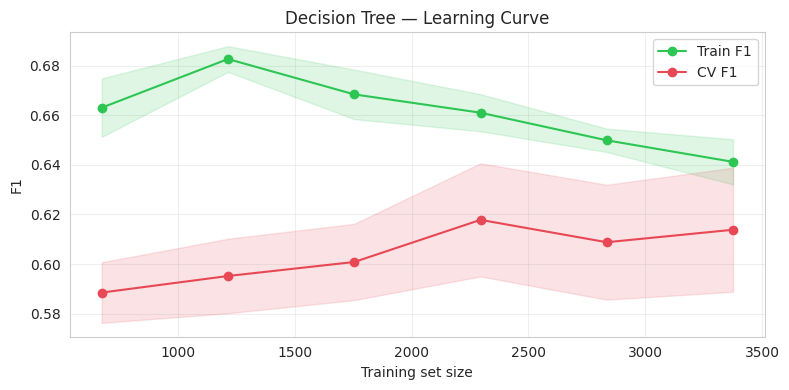

In [34]:
sizes, train_sc, val_sc = learning_curve(
    best_dt, X_train, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 4))
plt.plot(sizes, train_sc.mean(1), 'o-', label='Train F1', color='#2DC653')
plt.plot(sizes, val_sc.mean(1),   'o-', label='CV F1',    color='#E84855')
plt.fill_between(sizes, train_sc.mean(1)-train_sc.std(1), train_sc.mean(1)+train_sc.std(1),
                 alpha=0.15, color='#2DC653')
plt.fill_between(sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1),
                 alpha=0.15, color='#E84855')
plt.xlabel('Training set size'); plt.ylabel('F1')
plt.title('Decision Tree — Learning Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.6 Feature importance

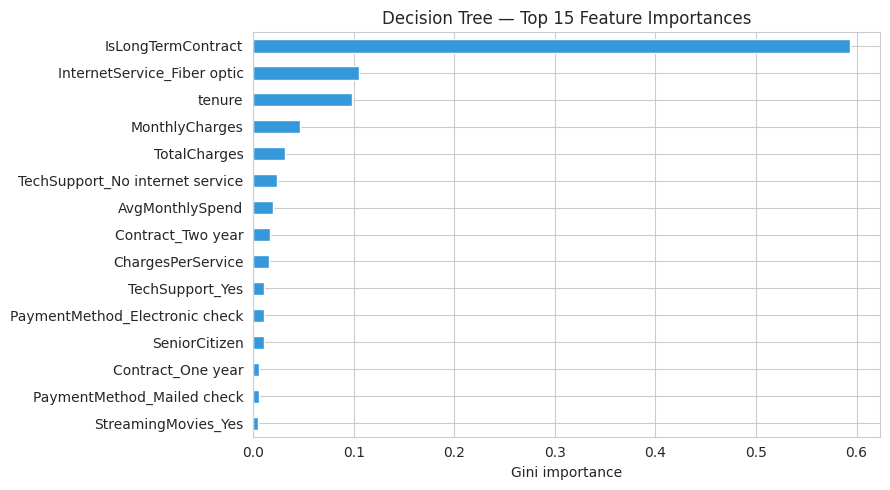

Top 5 features:
IsLongTermContract             0.5936
InternetService_Fiber optic    0.1055
tenure                         0.0987
MonthlyCharges                 0.0461
TotalCharges                   0.0315
dtype: float64


In [35]:
imp = (pd.Series(best_dt.feature_importances_, index=feature_names)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
imp.plot.barh(ax=ax, color='#3498db')
ax.invert_yaxis()
ax.set_title('Decision Tree — Top 15 Feature Importances')
ax.set_xlabel('Gini importance')
plt.tight_layout(); plt.show()

print('Top 5 features:')
print(imp.head(5).round(4))

### 4.7 Tree visualisation

Top 3 levels of the tuned tree.

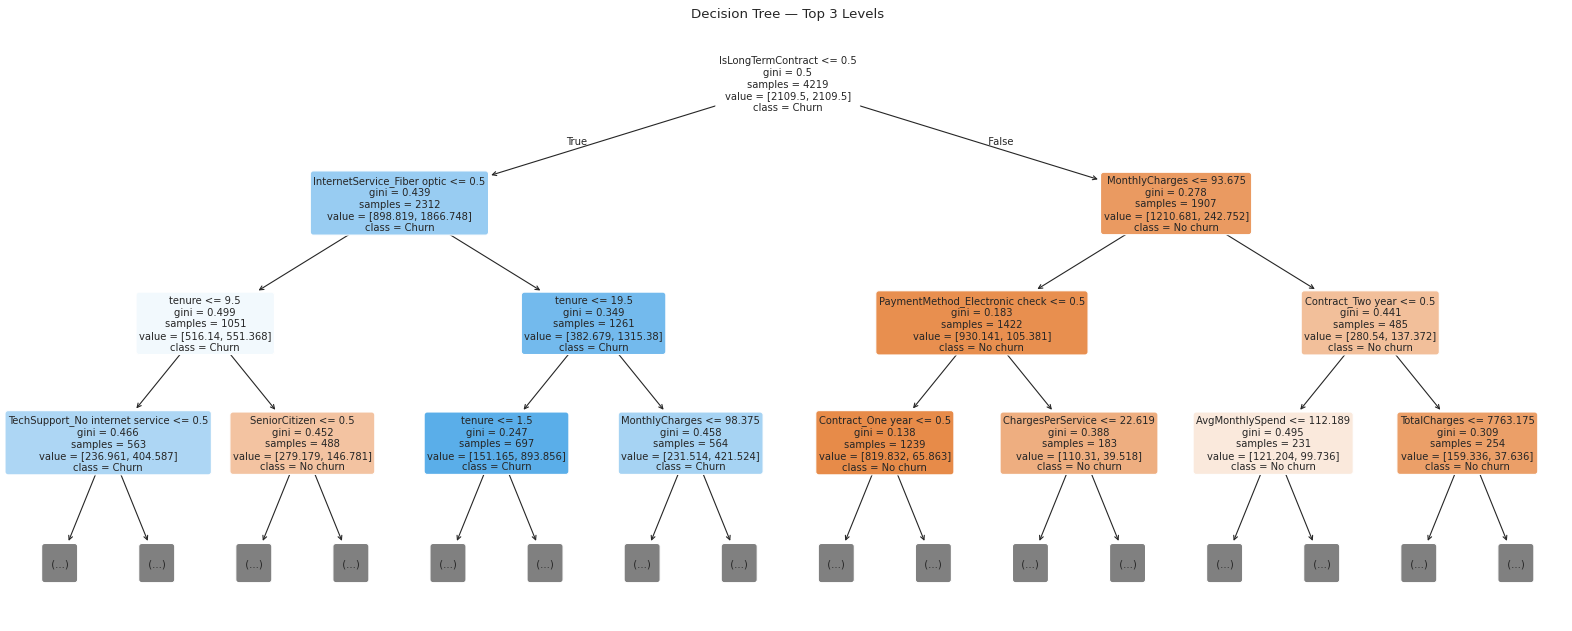

In [36]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(
    best_dt, max_depth=3, feature_names=feature_names,
    class_names=['No churn', 'Churn'], filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels')
plt.tight_layout(); plt.show()

### 4.8 Test set evaluation

In [37]:
y_test_pred_dt = best_dt.predict(X_test)
y_test_prob_dt = best_dt.predict_proba(X_test)[:, 1]

print('=== Tuned Decision Tree — Test ===')
print(classification_report(y_test, y_test_pred_dt,
                            target_names=['No churn', 'Churn'], zero_division=0))

dt_row = evaluate_enhanced(PRIMARY_NAME, best_dt, X_train, y_train, X_test, y_test)

=== Tuned Decision Tree — Test ===
              precision    recall  f1-score   support

    No churn       0.92      0.72      0.81      1033
       Churn       0.52      0.82      0.64       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407

=== Enhanced Evaluation: Decision Tree ===
  Accuracy   : 0.7484
  Precision  : 0.5168
  Recall     : 0.8235
  F1         : 0.6351
  ROC-AUC    : 0.8279
  MCC        : 0.4870
  Train F1   : 0.6492
  Test  F1   : 0.6351
  Overfit gap: 0.0142  [good fit]


### 4.9 Confusion matrix, ROC, Precision–Recall

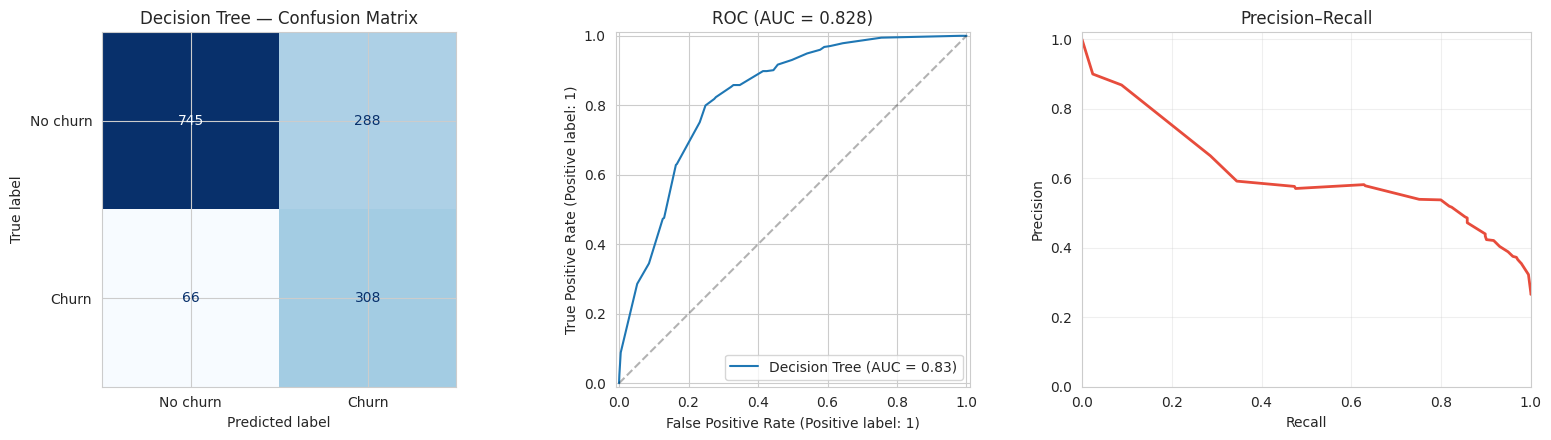

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_test, y_test_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'{PRIMARY_NAME} — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_test_prob_dt, ax=axes[1], name=PRIMARY_NAME)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title(f'ROC (AUC = {dt_row["ROC-AUC"]:.3f})')

prec_v, rec_v, _ = precision_recall_curve(y_test, y_test_prob_dt)
axes[2].plot(rec_v, prec_v, color='#e74c3c', lw=2)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision–Recall')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Shared Baseline: Logistic Regression

Linear, calibrated comparison point. Trained on scaled features.

### 5.1 Hyperparameter tuning

In [39]:
param_grid_lr = {
    'C'           : [0.01, 0.1, 1.0],
    'penalty'     : ['l2'],
    'class_weight': ['balanced'],
    'solver'      : ['liblinear'],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid_lr, cv=cv5, scoring='roc_auc', n_jobs=-1
)
print('Tuning Logistic Regression...')
grid_lr.fit(X_train_s, y_train)
best_lr = grid_lr.best_estimator_
print(f'Best params : {grid_lr.best_params_}')
print(f'Best CV AUC : {grid_lr.best_score_:.4f}')

Tuning Logistic Regression...
Best params : {'C': 1.0, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC : 0.8460


### 5.2 Validation evaluation

In [40]:
y_val_pred_lr = best_lr.predict(X_val_s)
y_val_prob_lr = best_lr.predict_proba(X_val_s)[:, 1]

print('=== Tuned Logistic Regression — Validation ===')
for k, v in evaluate('LR-tuned-val', y_val, y_val_pred_lr, y_val_prob_lr).items():
    print(f'  {k:10s}: {v}')

=== Tuned Logistic Regression — Validation ===
  Model     : LR-tuned-val
  Accuracy  : 0.7376
  Precision : 0.5042
  Recall    : 0.7968
  F1        : 0.6176
  ROC-AUC   : 0.833


### 5.3 Test set evaluation

In [41]:
y_test_pred_lr = best_lr.predict(X_test_s)
y_test_prob_lr = best_lr.predict_proba(X_test_s)[:, 1]

print('=== Tuned Logistic Regression — Test ===')
print(classification_report(y_test, y_test_pred_lr,
                            target_names=['No churn', 'Churn'], zero_division=0))

lr_row = evaluate_enhanced(SHARED_NAME, best_lr, X_train_s, y_train, X_test_s, y_test)

=== Tuned Logistic Regression — Test ===
              precision    recall  f1-score   support

    No churn       0.91      0.71      0.80      1033
       Churn       0.50      0.82      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.75      1407

=== Enhanced Evaluation: Logistic Regression ===
  Accuracy   : 0.7370
  Precision  : 0.5033
  Recall     : 0.8182
  F1         : 0.6232
  ROC-AUC    : 0.8485
  MCC        : 0.4689
  Train F1   : 0.6338
  Test  F1   : 0.6232
  Overfit gap: 0.0106  [good fit]


### 5.4 Coefficients

Magnitude shows contribution to log-odds. Positive coefficients push toward churn.

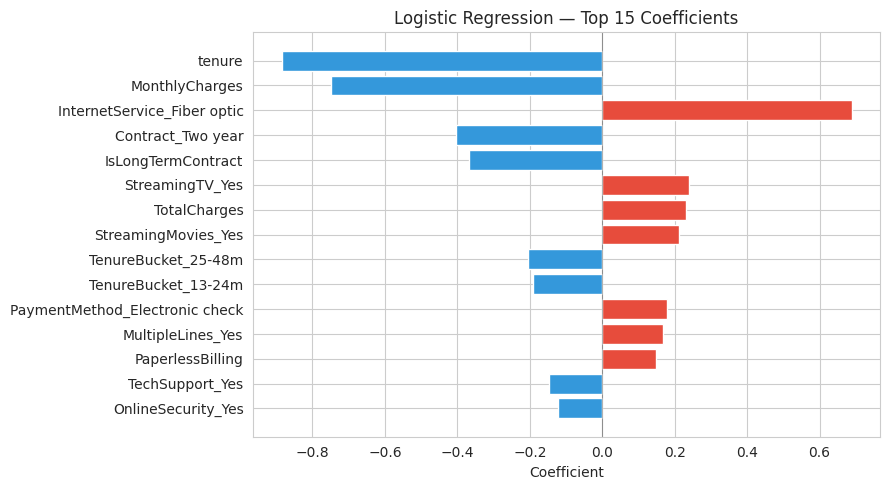

Top 5 features:
tenure                        -0.8849
MonthlyCharges                -0.7482
InternetService_Fiber optic    0.6882
Contract_Two year             -0.4040
IsLongTermContract            -0.3671
dtype: float64


In [42]:
coef = (pd.Series(best_lr.coef_[0], index=feature_names)
        .sort_values(key=lambda s: s.abs(), ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in coef.values]
ax.barh(coef.index[::-1], coef.values[::-1], color=colors[::-1])
ax.set_title('Logistic Regression — Top 15 Coefficients')
ax.set_xlabel('Coefficient')
ax.axvline(0, color='k', alpha=0.3, lw=0.8)
plt.tight_layout(); plt.show()

print('Top 5 features:')
print(coef.head(5).round(4))

### 5.5 Confusion matrix and ROC

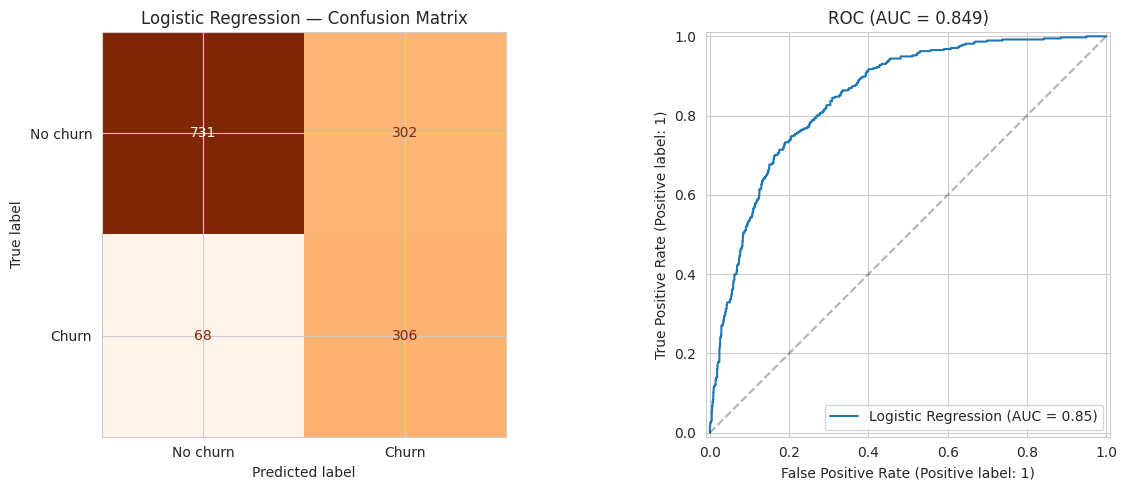

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['No churn', 'Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges'
)
axes[0].set_title(f'{SHARED_NAME} — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_test_prob_lr, ax=axes[1], name=SHARED_NAME)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title(f'ROC (AUC = {lr_row["ROC-AUC"]:.3f})')

plt.tight_layout(); plt.show()

### 5.6 PR-AUC

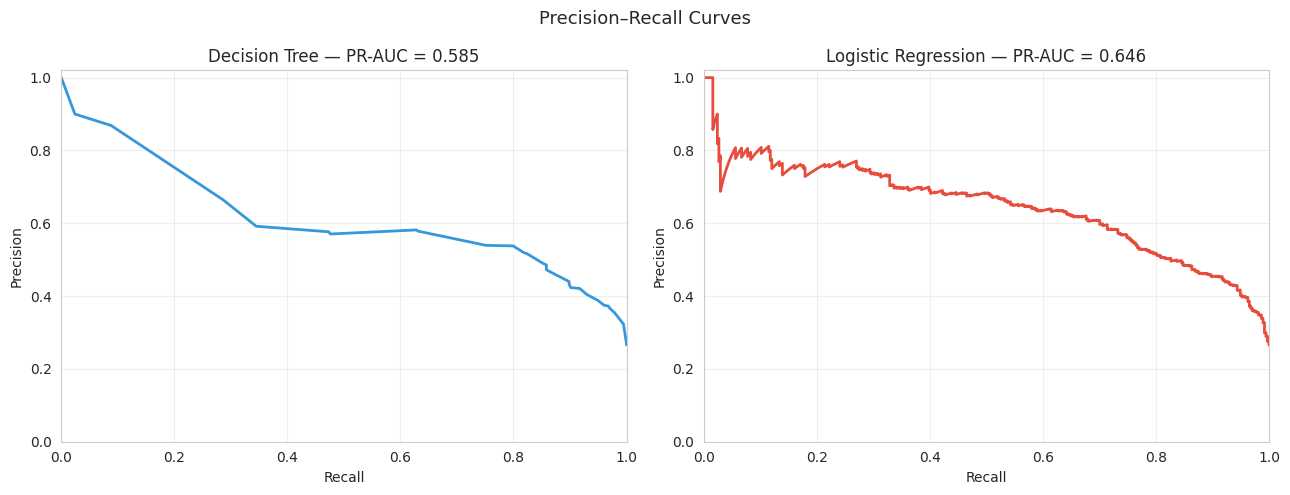

Decision Tree       PR-AUC: 0.5853
Logistic Regression PR-AUC: 0.6457


In [44]:
from sklearn.metrics import average_precision_score

pr_auc_dt = round(average_precision_score(y_test, y_test_prob_dt), 4)
pr_auc_lr = round(average_precision_score(y_test, y_test_prob_lr), 4)

dt_row['PR-AUC'] = pr_auc_dt
lr_row['PR-AUC'] = pr_auc_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_test_prob_dt)
axes[0].plot(rec_dt, prec_dt, color='#3498db', lw=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'{PRIMARY_NAME} — PR-AUC = {pr_auc_dt:.3f}')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.3)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_test_prob_lr)
axes[1].plot(rec_lr, prec_lr, color='#e74c3c', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'{SHARED_NAME} — PR-AUC = {pr_auc_lr:.3f}')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)

plt.suptitle('Precision–Recall Curves', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Decision Tree       PR-AUC: {pr_auc_dt}')
print(f'Logistic Regression PR-AUC: {pr_auc_lr}')

### 5.7 Strengths and weaknesses

**Strengths**
- Fast training and inference.
- Calibrated probability outputs.
- Coefficients are interpretable on scaled features.

**Weaknesses**
- Linear decision boundary; no interaction modelling.
- Sensitive to multicollinearity.
- Assumes additive feature contributions on the log-odds scale.

## 6. Comparison: Decision Tree vs Logistic Regression

=== Test Set Comparison ===
              Model  Accuracy  Precision  Recall     F1  ROC-AUC    MCC  Train_F1  Overfit_Gap Overfit_Label  PR-AUC
      Decision Tree    0.7484     0.5168  0.8235 0.6351   0.8279 0.4870    0.6492       0.0142      good fit  0.5853
Logistic Regression    0.7370     0.5033  0.8182 0.6232   0.8485 0.4689    0.6338       0.0106      good fit  0.6457


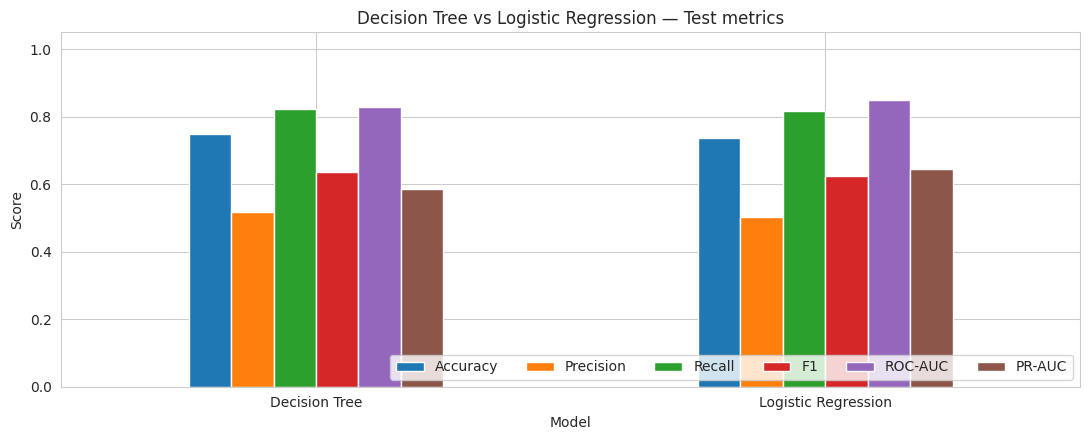

In [45]:
compare_df = pd.DataFrame([dt_row, lr_row])
print('=== Test Set Comparison ===')
print(compare_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC',
                  'MCC', 'Train_F1', 'Overfit_Gap', 'Overfit_Label', 'PR-AUC']].to_string(index=False))

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
fig, ax = plt.subplots(figsize=(11, 4.5))
compare_df.set_index('Model')[metric_cols].plot.bar(ax=ax, rot=0, edgecolor='white')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title(f'{PRIMARY_NAME} vs {SHARED_NAME} — Test metrics')
ax.legend(loc='lower right', ncol=6, frameon=True)
plt.tight_layout(); plt.show()

## 7. Save to results_log.csv

Appends two rows. Re-runs replace prior rows from the same notebook.

In [46]:
LOG = 'results_log.csv'

rows_to_add = []
for row_dict, role in [(dt_row, 'Primary'), (lr_row, 'Shared')]:
    rows_to_add.append({
        'Notebook'   : NOTEBOOK_ID,
        'Member'     : 'Abisha Jerlin Edison Prakash',
        'Role'       : role,
        'Model'      : row_dict['Model'],
        'Dataset'    : DATASET_NAME,
        'Accuracy'   : row_dict['Accuracy'],
        'Precision'  : row_dict['Precision'],
        'Recall'     : row_dict['Recall'],
        'F1'         : row_dict['F1'],
        'ROC-AUC'    : row_dict['ROC-AUC'],
        'MCC'        : row_dict['MCC'],
        'Overfit_Gap': row_dict['Overfit_Gap'],
        'PR-AUC'     : row_dict.get('PR-AUC', ''),
    })
new_rows = pd.DataFrame(rows_to_add)

if os.path.exists(LOG):
    log_df = pd.read_csv(LOG)
    if 'Notebook' in log_df.columns:
        log_df = log_df[log_df['Notebook'] != NOTEBOOK_ID]
else:
    log_df = pd.DataFrame()

log_df = pd.concat([log_df, new_rows], ignore_index=True)
log_df.to_csv(LOG, index=False)
print(f'Appended {len(new_rows)} rows. File now has {len(log_df)} rows total.')
print()
print(new_rows[['Notebook', 'Member', 'Role', 'Model', 'F1', 'ROC-AUC', 'MCC', 'PR-AUC']].to_string(index=False))

Appended 2 rows. File now has 2 rows total.

Notebook                       Member    Role               Model     F1  ROC-AUC    MCC  PR-AUC
    NB 1 Abisha Jerlin Edison Prakash Primary       Decision Tree 0.6351   0.8279 0.4870  0.5853
    NB 1 Abisha Jerlin Edison Prakash  Shared Logistic Regression 0.6232   0.8485 0.4689  0.6457


## 8. Cross-member comparison

Reads `results_log.csv` and displays all models currently saved.

In [47]:
all_results = pd.read_csv(LOG)
print(f'results_log.csv has {len(all_results)} rows from {all_results["Notebook"].nunique()} notebook(s).')
print(f'Models present: {sorted(all_results["Model"].unique())}')

display_cols = ['Notebook', 'Role', 'Model', 'F1', 'ROC-AUC', 'MCC', 'Overfit_Gap', 'PR-AUC']  # ← PR-AUC added
display_cols = [c for c in display_cols if c in all_results.columns]

print()
print('=== All rows in results_log.csv ===')
print(all_results[display_cols].to_string(index=False))

results_log.csv has 2 rows from 1 notebook(s).
Models present: ['Decision Tree', 'Logistic Regression']

=== All rows in results_log.csv ===
Notebook    Role               Model     F1  ROC-AUC    MCC  Overfit_Gap  PR-AUC
    NB 1 Primary       Decision Tree 0.6351   0.8279 0.4870       0.0142  0.5853
    NB 1  Shared Logistic Regression 0.6232   0.8485 0.4689       0.0106  0.6457


In [48]:
if 'Role' in all_results.columns:
    role_clean = all_results['Role'].astype(str).str.strip().str.lower()
    primary = all_results[role_clean == 'primary'].copy()
    shared = all_results[role_clean == 'shared'].copy()
else:
    primary = all_results.drop_duplicates(subset=['Notebook', 'Model', 'Dataset']).copy()
    shared = pd.DataFrame()

print(f"Primary rows found: {len(primary)}")

primary_cols = ['Notebook', 'Member', 'Role', 'Model', 'Dataset', 'F1', 'ROC-AUC', 'PR-AUC']
primary_cols = [c for c in primary_cols if c in primary.columns]
display(primary[primary_cols])

if len(primary) >= 2:
    for dataset in primary['Dataset'].unique():
        temp = primary[primary['Dataset'] == dataset].copy()

        if len(temp) < 2:
            print(f"Only one primary model found for {dataset}; skipping cross-member chart.")
            continue

        fig, ax = plt.subplots(figsize=(11, 4.5))

        x = np.arange(len(temp))
        width = 0.25

        ax.bar(x - width, temp['F1'], width, label='F1', color='#3498db')
        ax.bar(x, temp['ROC-AUC'], width, label='ROC-AUC', color='#9b59b6')

        if 'PR-AUC' in temp.columns:
            ax.bar(x + width, temp['PR-AUC'], width, label='PR-AUC', color='#e67e22')

        ax.set_xticks(x)
        ax.set_xticklabels(temp['Model'], rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.set_title(f'Cross-member comparison — Primary models ({dataset})')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3, axis='y')

        for i, row in temp.reset_index(drop=True).iterrows():
            ax.text(i - width, row['F1'] + 0.01, f"{row['F1']:.3f}", ha='center', fontsize=8)
            ax.text(i, row['ROC-AUC'] + 0.01, f"{row['ROC-AUC']:.3f}", ha='center', fontsize=8)

            if 'PR-AUC' in temp.columns and pd.notna(row['PR-AUC']):
                ax.text(i + width, row['PR-AUC'] + 0.01, f"{row['PR-AUC']:.3f}", ha='center', fontsize=8)

        plt.tight_layout()
        plt.show()
else:
    print("Not enough primary model rows for cross-member comparison yet.")
    print("This chart will appear after at least two individual notebooks have saved primary model results.")



if len(shared) >= 1:
    print()
    print('=== Shared Logistic Regression benchmark across members ===')

    shared_cols = ['Notebook', 'Member', 'Dataset', 'Model', 'F1', 'ROC-AUC', 'PR-AUC', 'MCC']
    shared_cols = [c for c in shared_cols if c in shared.columns]

    display(shared[shared_cols].sort_values(['Dataset', 'Notebook']))
else:
    print("No shared Logistic Regression rows found.")

Primary rows found: 1


,Notebook,Member,Role,Model,Dataset,F1,ROC-AUC,PR-AUC
0,NB 1,Abisha Jerlin Edison Prakash,Primary,Decision Tree,Telco-Churn,0.6351,0.8279,0.5853


Not enough primary model rows for cross-member comparison yet.
This chart will appear after at least two individual notebooks have saved primary model results.

=== Shared Logistic Regression benchmark across members ===


,Notebook,Member,Dataset,Model,F1,ROC-AUC,PR-AUC,MCC
1,NB 1,Abisha Jerlin Edison Prakash,Telco-Churn,Logistic Regression,0.6232,0.8485,0.6457,0.4689


In [49]:

# Metric summary table — Decision Tree vs Logistic Regression


metric_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "MCC",
        "Overfit Gap"
    ],
    "Decision Tree": [
        dt_row["Accuracy"],
        dt_row["Precision"],
        dt_row["Recall"],
        dt_row["F1"],
        dt_row["ROC-AUC"],
        dt_row["PR-AUC"],
        dt_row["MCC"],
        dt_row["Overfit_Gap"]
    ],
    "Logistic Regression": [
        lr_row["Accuracy"],
        lr_row["Precision"],
        lr_row["Recall"],
        lr_row["F1"],
        lr_row["ROC-AUC"],
        lr_row["PR-AUC"],
        lr_row["MCC"],
        lr_row["Overfit_Gap"]
    ]
})

display(metric_table)

,Metric,Decision Tree,Logistic Regression
0,Accuracy,0.7484,0.7370
1,Precision,0.5168,0.5033
2,Recall,0.8235,0.8182
3,F1-score,0.6351,0.6232
4,ROC-AUC,0.8279,0.8485
5,PR-AUC,0.5853,0.6457
6,MCC,0.4870,0.4689
7,Overfit Gap,0.0142,0.0106


## 9. Interpretation and Business Recommendations

### 9.1 Model Performance Summary

Both models were evaluated on the same held-out test set representing 20%
of the 7,043 Telco customer records. Using the same test set ensures a
fair comparison as both models faced identical unseen data.

| Metric | Decision Tree | Logistic Regression |
|---|---:|---:|
| Accuracy | 0.7484 | 0.7370 |
| Precision | 0.5168 | 0.5033 |
| Recall | 0.8235 | 0.8182 |
| F1-score | 0.6351 | 0.6232 |
| ROC-AUC | 0.8279 | 0.8485 |
| PR-AUC | 0.5853 | 0.6457 |
| MCC | 0.4870 | 0.4689 |
| Overfit Gap | 0.0142 | 0.0106 |

The Decision Tree performed better on Accuracy, Precision, Recall, F1-score
and MCC. Logistic Regression achieved stronger ROC-AUC and PR-AUC, meaning
it ranks customers by churn probability more smoothly across thresholds.
Both models had overfit gaps well below 0.05, confirming they generalise
well to unseen data.

### 9.2 Evidence Supporting Model Selection

Model selection was not based on accuracy alone. The dataset has a 26.5%
churn rate, meaning it is imbalanced. A model could achieve reasonable
accuracy by mostly predicting the majority class, while still missing many
actual churners.

Recall was treated as the most important metric because the business goal
is to catch as many churning customers as possible before they leave. A
false negative missing a customer who churns results in lost revenue.
A false positive flagging a loyal customer only costs a small retention
offer.

The Decision Tree achieved the highest Recall (0.8235) and F1-score
(0.6351). MCC was also considered as it gives a balanced view of
classification quality on imbalanced data the Decision Tree scored
higher here too (0.4870). Beyond metrics, the Decision Tree produces
readable decision rules which help senior management understand why a
customer was flagged, making findings more credible and actionable.

### 9.3 Which Model is Better and Why?

The Decision Tree is recommended as the primary operational model. It
outperforms Logistic Regression on Recall, F1, Precision, Accuracy and
MCC, while keeping a low overfit gap making it well suited for
identifying at-risk customers.

Logistic Regression is still valuable. Its higher ROC-AUC (0.8485) and
PR-AUC (0.6457) make it better for ranking customers by churn risk across
different probability thresholds. It is therefore more suitable for
management dashboards and risk-scoring reports.

In summary use the Decision Tree for operational churn alerts, and
Logistic Regression for executive reporting and customer ranking.

### 9.4 Key Drivers of Churn

Both models identified the same top churn drivers, which strengthens
confidence in the findings:

- **Contract type** — Month-to-month customers churn far more than
  customers on 1 or 2 year contracts. This is the strongest driver in
  both models.
- **Tenure** — Customers in their first 12 months are the highest-risk
  group. TenureBucket features confirm early-stage attrition is the
  main problem.
- **Internet service (Fibre optic)** — Fibre customers show higher churn,
  possibly due to price sensitivity or unmet service expectations.
- **Monthly charges** — Higher monthly bills correlate with increased
  churn risk, pointing to affordability as a key factor.

### 9.5 Recommendations to Senior Management

1. **Convert month-to-month customers to annual contracts** — Offer
   targeted incentives such as one free month or a loyalty discount.
   This directly addresses the strongest churn driver.

2. **Launch a new-customer retention programme** — Use the Decision Tree
   to flag customers in their first 12 months with a churn probability
   above 0.5 for proactive outreach such as a loyalty call or service
   review.

3. **Investigate fibre optic service quality** — Run a customer
   satisfaction survey for fibre users. A service credit or speed
   upgrade could reduce attrition in this segment at low cost.

4. **Review pricing for high monthly-charge customers** — Introduce
   loyalty pricing tiers for customers paying above the median monthly
   charge, especially those on month-to-month contracts, as both risk
   factors compound each other.

### 9.6 Limitations

The model was trained on historical data, so its accuracy depends on
future customer behaviour following similar patterns. If market conditions,
pricing or service quality change significantly, the model should be
retrained.

The model identifies relationships but does not prove the exact cause of
churn. For example, fibre optic customers may churn more, but the model
cannot confirm whether this is due to price, service issues or contract
structure. It should therefore be used alongside customer feedback and
commercial judgement.

Finally, not every flagged customer should automatically receive a discount.
The model should be combined with business rules so retention offers are
only made where the expected saved revenue outweighs the cost of the
intervention.

### 9.7 Cross-Member Context

The group used Logistic Regression as the shared baseline model across all
five notebooks, allowing a consistent comparison of the shared model
performance. Each member implemented a unique primary model: Decision Tree
(NB1), Gaussian Naive Bayes (NB2), k-Nearest Neighbours (NB3), MLP Neural
Network (NB4) and Linear SVM (NB5).

Once all members' results are consolidated in results_log.csv, the full
group comparison will show how the Decision Tree performs against all other
primary models. Based on results available so far, the Decision Tree
achieves strong Recall (0.8235) and F1-score (0.6351), making it one of
the better performing models for identifying churning customers. The shared
Logistic Regression results are consistent across all notebooks, which
confirms the stability of the preprocessing pipeline and the train/test
split used by the group.